# Overview

**EnergyFM** is a family of **domain-specific Time Series Foundation Models (TSFMs)** for energy meter data analytics. Pretrained on **1.26 billion hourly electricity consumption readings** from **76,000+ buildings**, EnergyFM provides powerful representations for a wide range of downstream energy applications while remaining lightweight and computationally efficient.

The project currently includes two pretrained models:

* **Energy-TTM** – A forecasting foundation model built upon IBM Research's **Tiny Time Mixer (TTM)** architecture, optimized for **short-term load forecasting**.
* **Energy-TSPulse** – A reconstruction-based foundation model adapted from IBM Research's **TSPulse** architecture for **energy anomaly detection**, **appliance classification**, and **missing value imputation**.

EnergyFM supports both **zero-shot inference** and **task-specific fine-tuning**, enabling practitioners to deploy pretrained models on new buildings with minimal labeled data.

### Resources

* **Project Website:** https://energyfms.github.io/
* **Paper:** https://dl.acm.org/doi/10.1145/3744255.3798119
* **GitHub Repository:** https://github.com/energyfms
* **Hugging Face Models:** https://huggingface.co/EnergyFM
* **Tutorial Notebooks:** https://github.com/energyfms/notebooks

If you use **EnergyFM** in your research or applications, please consider citing our paper


# Fine-Tuning EnergyTTM for Short-Term Load Forecasting

In this notebook, we demonstrate how to **fine-tune** the pretrained model for **Short-Term Load Forecasting (STLF)** using labeled energy consumption data, enabling improved performance on a target dataset.

<a target="_blank" href="https://colab.research.google.com/github/energyfms/notebooks/blob/main/energy_ttm_finetuning.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



### What is Short-Term Load Forecasting (STLF)?

**Short-Term Load Forecasting (STLF)** predicts future electricity demand over the next few hours or days using historical consumption data. Reliable forecasts are critical for:

- Power grid operation and load balancing
- Demand response and energy optimization
- Smart building energy management
- Improving efficiency and reducing operational costs

This notebook focuses on the common **day-ahead forecasting** task, where the model predicts the **next 24 hours** of electricity demand from the **previous 7 days** of observations.



### Experiment Setup


In this notebook, you will:

- Load a pretrained **EnergyTTM** checkpoint
- Fine-tune the model on the target forecasting dataset
- Generate forecasts for unseen buildings
- Compare predictions with ground truth


| Setting | Value |
|---------|-------|
| Model | **EnergyTTM (Pretrained)** |
| Training | Fine-Tuning using first 6 months of data |
| Context Length | **168 hours** (Previous 7 days) |
| Forecast Horizon | **24 hours** (Next day) |
| Evaluation | Rolling forecat on last 6 months of data |
| Metric | Mean Absolute Error |




### Install Granite-TSFM dependencies

In [1]:
# ! pip install "granite-tsfm[notebooks] @ git+https://github.com/ibm-granite/granite-tsfm.git"

In [2]:
import os
import random 
import math 
import tempfile 
import torch 
import pickle 
import logging 
import warnings
import json
import torch.nn as nn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np 
import pandas as pd
from transformers import  set_seed
from torch.utils.data import ConcatDataset, Dataset, DataLoader
from tsfm_public.models.tinytimemixer.configuration_tinytimemixer import TinyTimeMixerConfig
from tsfm_public.models.tinytimemixer import TinyTimeMixerForPrediction

warnings.filterwarnings("ignore")
SEED = 42
set_seed(SEED)


In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/energyfms/notebooks/refs/heads/main/Dataset/Forecasting/sample_building_ashrae.csv")

In [4]:
df.head()

,timestamp,meter_reading
0,2016-01-01 00:00:00,3.4
1,2016-01-01 01:00:00,1.8
2,2016-01-01 02:00:00,2.2
3,2016-01-01 03:00:00,2.2
4,2016-01-01 04:00:00,2.3


In [5]:

# Set index
df.set_index("timestamp", inplace=True)
df.index = pd.to_datetime(df.index)
# Ensure numeric
df["meter_reading"] = pd.to_numeric(df["meter_reading"], errors="coerce")


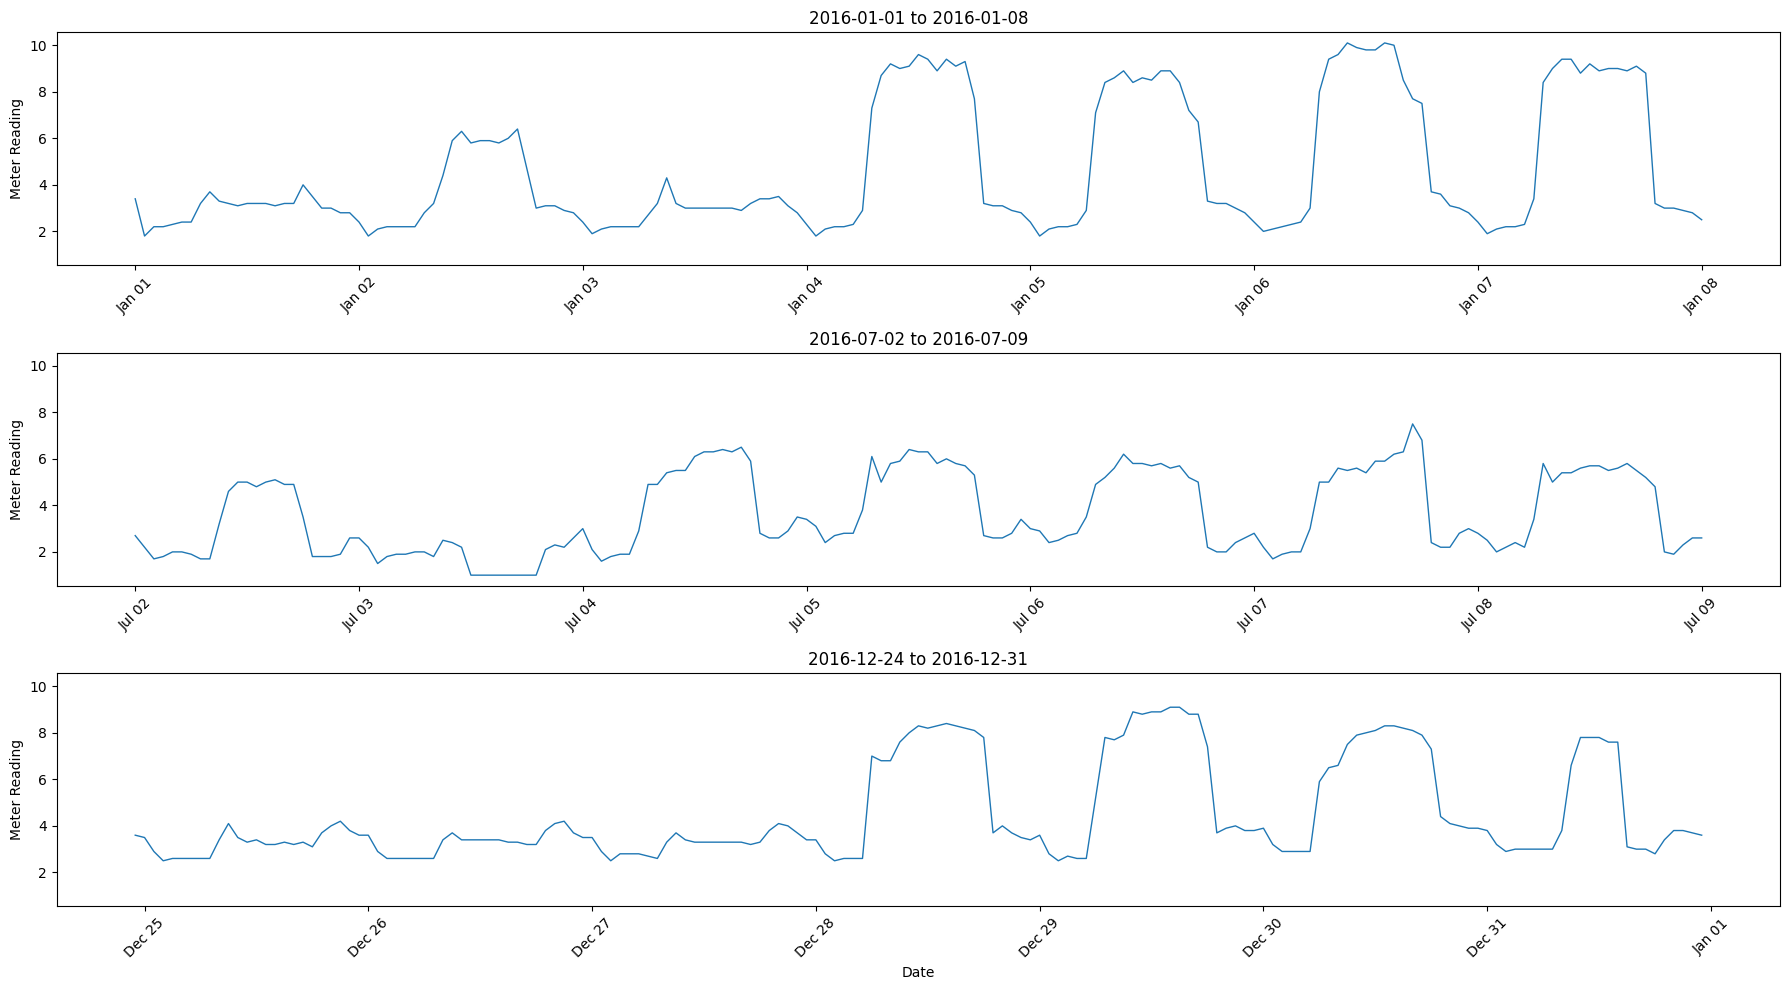

In [6]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Number of weeks to display
num_windows = 3
window = pd.Timedelta(days=7)

# Starting indices (beginning, middle, end)
starts = [
    df.index[0],
    df.index[len(df)//2],
    df.index[-1] - window
]

fig, axes = plt.subplots(num_windows, 1, figsize=(18, 10), sharey=True)

for ax, start in zip(axes, starts):
    end = start + window
    week = df.loc[start:end]

    ax.plot(week.index, week["meter_reading"], linewidth=1)

    ax.set_title(f"{start.date()} to {end.date()}")
    ax.set_ylabel("Meter Reading")

    # Tick every day
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

    plt.setp(ax.get_xticklabels(), rotation=45)

axes[-1].set_xlabel("Date")

plt.tight_layout()
plt.show()

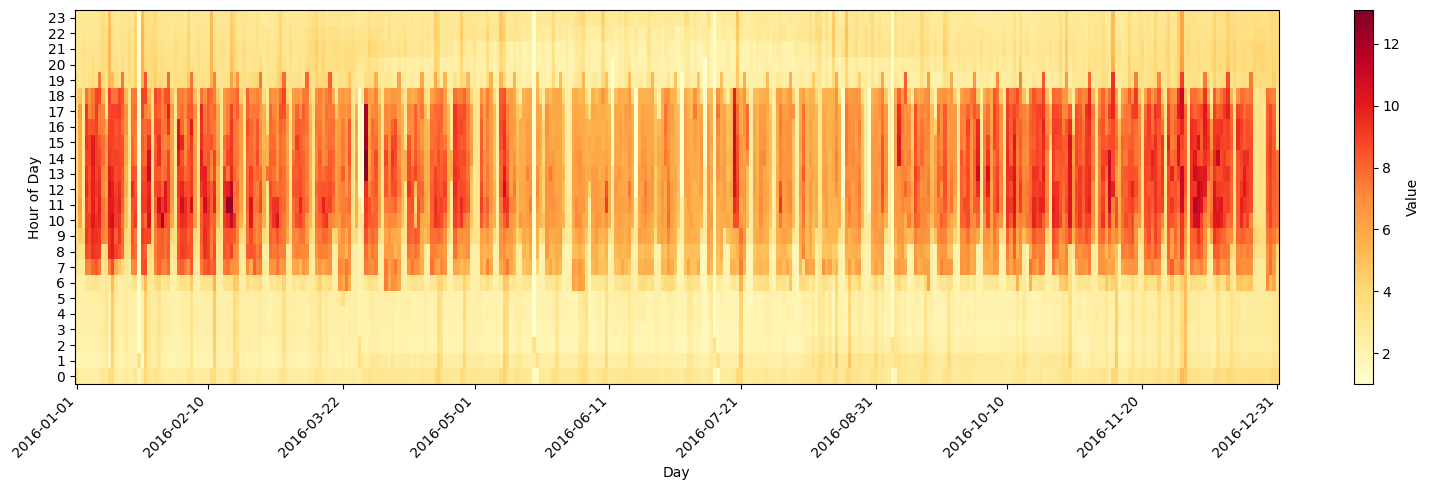

In [7]:

heatmap = df.copy()
heatmap["day"] = heatmap.index.date
heatmap["hour"] = heatmap.index.hour

# Hours × Days
heatmap = heatmap.pivot_table(
    index="hour",
    columns="day",
    values="meter_reading"
)

fig, ax = plt.subplots(figsize=(16, 5))

im = ax.imshow(
    heatmap.values,
    aspect="auto",
    origin="lower",
    interpolation="nearest",
    cmap="YlOrRd"
)

# Hour labels
ax.set_yticks(np.arange(24))
ax.set_ylabel("Hour of Day")

# Show about 10 evenly spaced day labels
xticks = np.linspace(0, heatmap.shape[1]-1, 10, dtype=int)
ax.set_xticks(xticks)
ax.set_xticklabels(
    [str(heatmap.columns[i]) for i in xticks],
    rotation=45,
    ha="right"
)
ax.set_xlabel("Day")

plt.colorbar(im, ax=ax, label="Value")
plt.tight_layout()
plt.show()

In [8]:
print(df.isna().sum())
df.describe()

meter_reading    0
dtype: int64


,meter_reading
count,8784.000000
mean,4.565478
std,2.436957
min,1.000000
25%,2.500000
50%,3.400000
75%,6.600000
max,13.100000


### Spliting Fine-Tune and Test data

In [9]:
split_idx = int(len(df) // 1.5) # 9months for training, 3 months for testing

train = df.iloc[:split_idx].copy()
test  = df.iloc[split_idx:].copy()

print("Train range:", train.index.min(), "→", train.index.max())
print("Test range :", test.index.min(),  "→", test.index.max())

Train range: 2016-01-01 00:00:00 → 2016-08-31 23:00:00
Test range : 2016-09-01 00:00:00 → 2016-12-31 23:00:00


## EnergyTTM

#### Loading EnergyTTM (168-24-commercial)
The current variant is pretrained on synthetic commercial data, and is inteded to be used for commercial building data. User may experiment with other variants depending on use case.

In [10]:

device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
args = {
    "num_input_channels": 1,
    "context_length": 168,  # 1 week of hourly data
    "prediction_length": 24,   # Forecasting next 24 hours
    "patch_stride": 24,
}


# Initialize Model

ttm_model = TinyTimeMixerForPrediction.from_pretrained(
    "EnergyFM/energy-ttm",  
    revision="main", # model revision: 168-24-res, 512-96-comm, 512-96-res
    num_input_channels=1,  
).to(device)

#### Helper function for pre-processing and evaluation

In [11]:

def standardize_series(series, eps=1e-8):
    mean = np.mean(series)
    std = np.std(series)
    standardized_series = (series - mean) / (std+eps)
    return standardized_series, mean, std

def unscale_predictions(predictions, mean, std, eps=1e-8):
    return predictions * (std+eps) + mean




### Custom Torch Dataset for EnergyTTM

In [12]:

class TimeSeriesDataset(Dataset):
    def __init__(self, data, backcast_length, forecast_length, stride=1):
        # Standardize the time series data
        self.data, self.mean, self.std = standardize_series(data)
        self.backcast_length = backcast_length
        self.forecast_length = forecast_length
        self.stride = stride

    def __len__(self):
        return (len(self.data) - self.backcast_length - self.forecast_length) // self.stride + 1

    def __getitem__(self, index):
        start_index = index * self.stride
        x = self.data[start_index : start_index + self.backcast_length]
        y = self.data[start_index + self.backcast_length : start_index + self.backcast_length + self.forecast_length]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)


In [13]:
def create_dataset_if_valid(energy_data, args):

    # Minimum required length to form at least one training sample
    min_required = args["context_length"] + args["prediction_length"]

    # Skip if series is too short
    if len(energy_data) < min_required:
        print("   Too short, skipping...")
        return None

    # Create dataset using sliding windows
    dataset = TimeSeriesDataset(
        energy_data,
        args["context_length"],
        args["prediction_length"],
        args["patch_stride"]
    )

    # Ensure dataset contains at least one sample
    if len(dataset) == 0:
        print("   No samples, skipping...")
        return None

    return dataset



#### Intialising Train and Test Dataset

In [14]:
test_dataset = create_dataset_if_valid(test["meter_reading"].values, args)  
train_dataset = create_dataset_if_valid(train["meter_reading"].values, args=args)
print("Test size:", len(test_dataset))
print("Train size:", len(train_dataset))
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

Test size: 115
Train size: 237


### Zero Shot Energy-TTM

In [15]:

ttm_model.eval()

criterion = nn.MSELoss()

val_losses = []
y_true_test = []
y_pred_test_ttm = []

# Iterate over dataset one sample at a time
for x_test, y_test in test_loader:

    # Add channel dimension and move to device
    x_test = x_test.unsqueeze(-1).to(device)
    y_test = y_test.to(device)

    with torch.no_grad():
        # Forward pass
        output = ttm_model(x_test)
        forecast = output.prediction_outputs.squeeze(-1)

        # Compute loss
        loss = criterion(forecast, y_test)

        # Skip if loss is NaN
        if torch.isnan(loss):
            continue

        # Store results
        val_losses.append(loss.item())
        y_true_test.append(y_test.cpu().numpy())
        y_pred_test_ttm.append(forecast.cpu().numpy())

# If no valid predictions collected
if len(y_true_test) == 0:
    y_true_test = np.array([])
    y_pred_test_ttm = np.array([])

# Concatenate predictions and ground truth
y_true_ttm_zs = np.concatenate(y_true_test, axis=0)
y_pred_ttm_zs = np.concatenate(y_pred_test_ttm, axis=0)



In [16]:
mean = test_dataset.mean
std  = test_dataset.std

y_true_flat_zs = y_true_ttm_zs.reshape(-1)
y_pred_flat_zs = y_pred_ttm_zs.reshape(-1)


y_true_unscaled_ttm_zs = unscale_predictions(y_true_flat_zs, mean, std)
y_pred_unscaled_ttm_zs = unscale_predictions(y_pred_flat_zs, mean, std)


### Applying transfer learning setup 

In [17]:
# Freeze everything
for param in ttm_model.parameters():
    param.requires_grad = False

trainable_layers = []

# Unfreeze only normalization layers and bias terms
for name, param in ttm_model.named_parameters():

    lname = name.lower()

    if (lname.endswith(".norm") or ".norm" in lname) or (
        lname.endswith(".bias")
        or ".bias" in lname
    ):
        param.requires_grad = True
        trainable_layers.append(name)

print("\nTrainable layers:")
for layer in trainable_layers:
    print(layer)

trainable = sum(p.numel() for p in ttm_model.parameters() if p.requires_grad)
total = sum(p.numel() for p in ttm_model.parameters())

print(f"\nTrainable params: {trainable:,}")
print(f"Total params:     {total:,}")
print(f"Percentage:       {100*trainable/total:.2f}%")

criterion = torch.nn.MSELoss()

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, ttm_model.parameters()),
    lr=5e-4,
)


Trainable layers:
backbone.encoder.patcher.bias
backbone.encoder.mlp_mixer_encoder.mixers.0.mixer_layers.0.patch_mixer.norm.norm.weight
backbone.encoder.mlp_mixer_encoder.mixers.0.mixer_layers.0.patch_mixer.norm.norm.bias
backbone.encoder.mlp_mixer_encoder.mixers.0.mixer_layers.0.patch_mixer.mlp.fc1.bias
backbone.encoder.mlp_mixer_encoder.mixers.0.mixer_layers.0.patch_mixer.mlp.fc2.bias
backbone.encoder.mlp_mixer_encoder.mixers.0.mixer_layers.0.patch_mixer.gating_block.attn_layer.bias
backbone.encoder.mlp_mixer_encoder.mixers.0.mixer_layers.0.feature_mixer.norm.norm.weight
backbone.encoder.mlp_mixer_encoder.mixers.0.mixer_layers.0.feature_mixer.norm.norm.bias
backbone.encoder.mlp_mixer_encoder.mixers.0.mixer_layers.0.feature_mixer.mlp.fc1.bias
backbone.encoder.mlp_mixer_encoder.mixers.0.mixer_layers.0.feature_mixer.mlp.fc2.bias
backbone.encoder.mlp_mixer_encoder.mixers.0.mixer_layers.0.feature_mixer.gating_block.attn_layer.bias
backbone.encoder.mlp_mixer_encoder.mixers.0.mixer_layers.

## Finetuning EnergyTTM

In [18]:
num_epochs = 50
criterion = torch.nn.MSELoss()

for epoch in range(num_epochs):

    ttm_model.train()   # Enable training mode
    train_losses = []
    
    for x_train, y_train in train_loader:
        x_train = x_train.unsqueeze(-1).to(device)
        y_train = y_train.to(device)

        optimizer.zero_grad()

        output = ttm_model(x_train)
        forecast = output.prediction_outputs.squeeze(-1)
        loss = criterion(forecast, y_train)
        loss.backward()

        # Update weights
        optimizer.step()

        train_losses.append(loss.item())

    avg_train_loss = sum(train_losses) / len(train_losses)

    # print(f"Epoch [{epoch+1}/{num_epochs}] "
        #   f"Train Loss: {avg_train_loss:.6f}")


### Inferencing Fine-tuned Energy-TTM

In [19]:

ttm_model.eval()

val_losses = []
y_true_test = []
y_pred_test_ttm = []

# Iterate over dataset one sample at a time
for x_test, y_test in test_loader:

    # Add channel dimension and move to device
    x_test = x_test.unsqueeze(-1).to(device)
    y_test = y_test.to(device)

    with torch.no_grad():
        # Forward pass
        output = ttm_model(x_test)
        forecast = output.prediction_outputs.squeeze(-1)

        # Compute loss
        loss = criterion(forecast, y_test)

        # Skip if loss is NaN
        if torch.isnan(loss):
            continue

        # Store results
        val_losses.append(loss.item())
        y_true_test.append(y_test.cpu().numpy())
        y_pred_test_ttm.append(forecast.cpu().numpy())

# If no valid predictions collected
if len(y_true_test) == 0:
    y_true_test = np.array([])
    y_pred_test_ttm = np.array([])

# Concatenate predictions and ground truth
y_true_ttm_ft = np.concatenate(y_true_test, axis=0)
y_pred_ttm_ft = np.concatenate(y_pred_test_ttm, axis=0)



In [20]:
mean = test_dataset.mean
std  = test_dataset.std

y_true_flat_ft = y_true_ttm_ft.reshape(-1)
y_pred_flat_ft = y_pred_ttm_ft.reshape(-1)


y_true_unscaled_ttm_ft = unscale_predictions(y_true_flat_ft, mean, std)
y_pred_unscaled_ttm_ft = unscale_predictions(y_pred_flat_ft, mean, std)


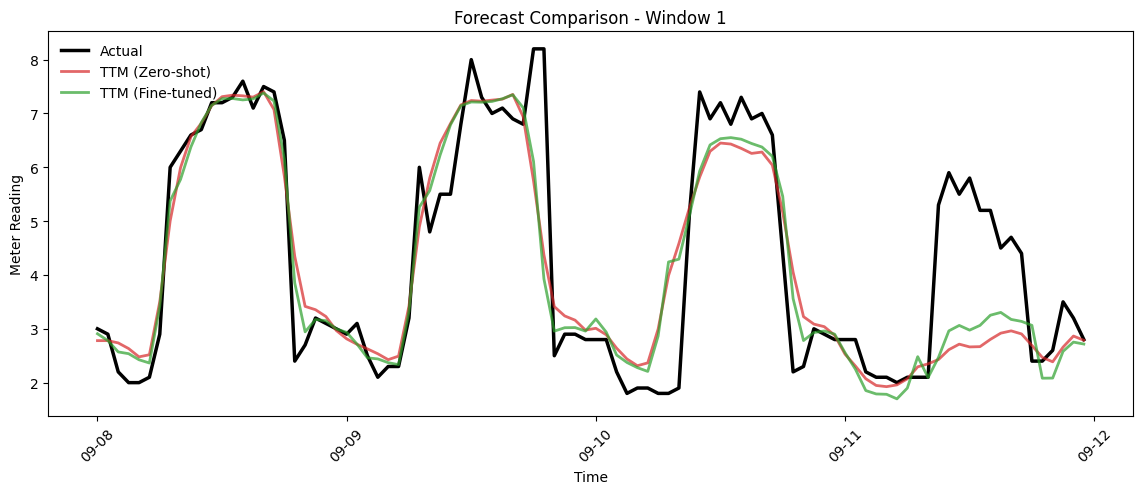

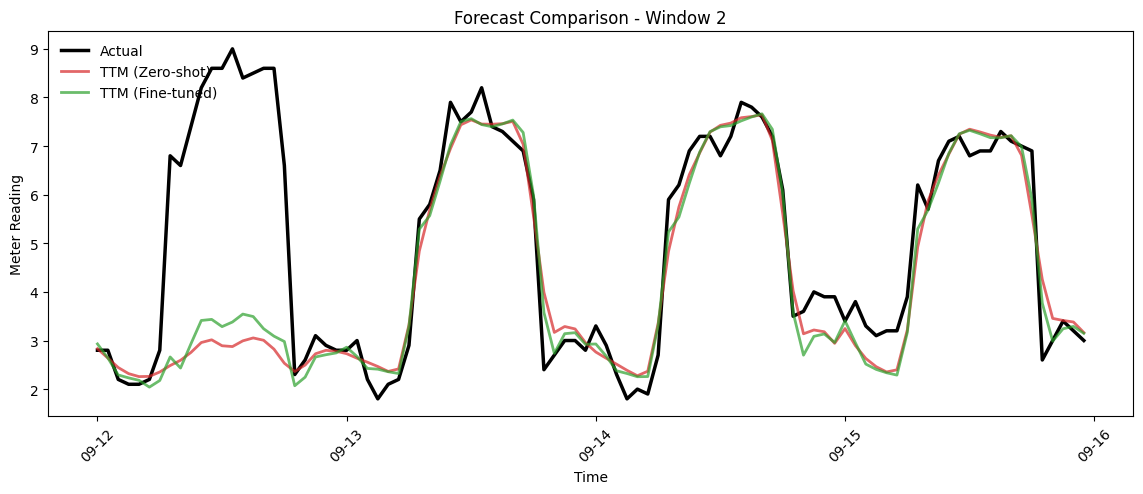

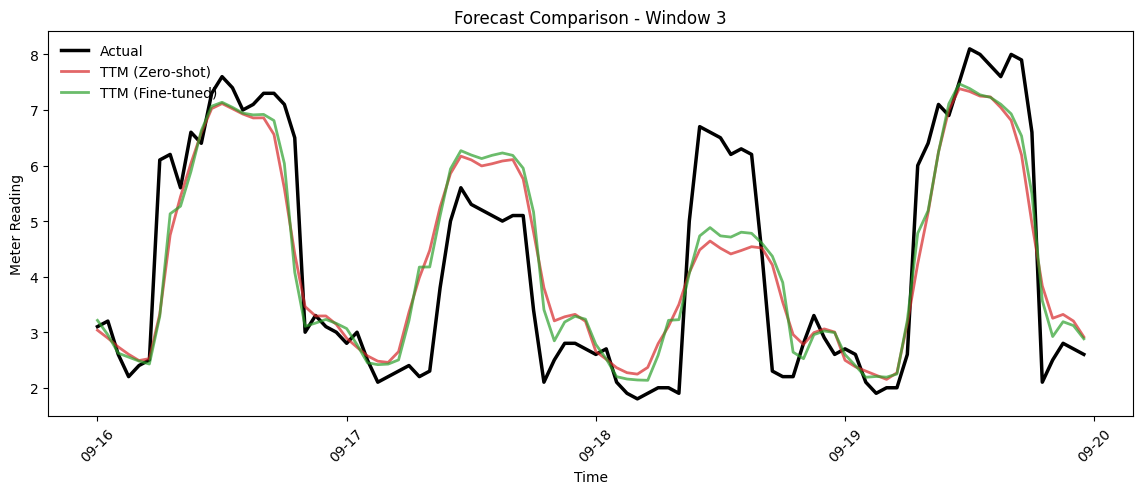

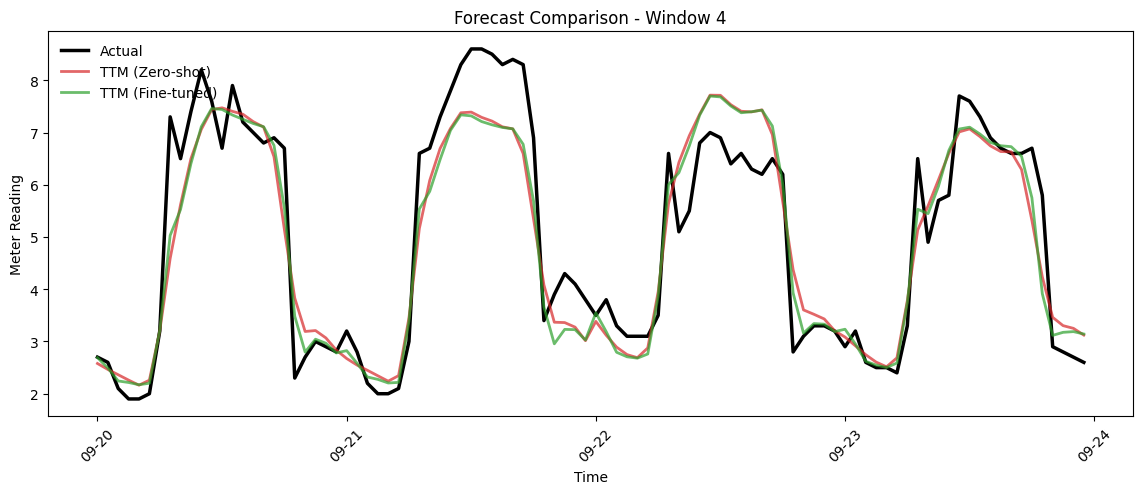

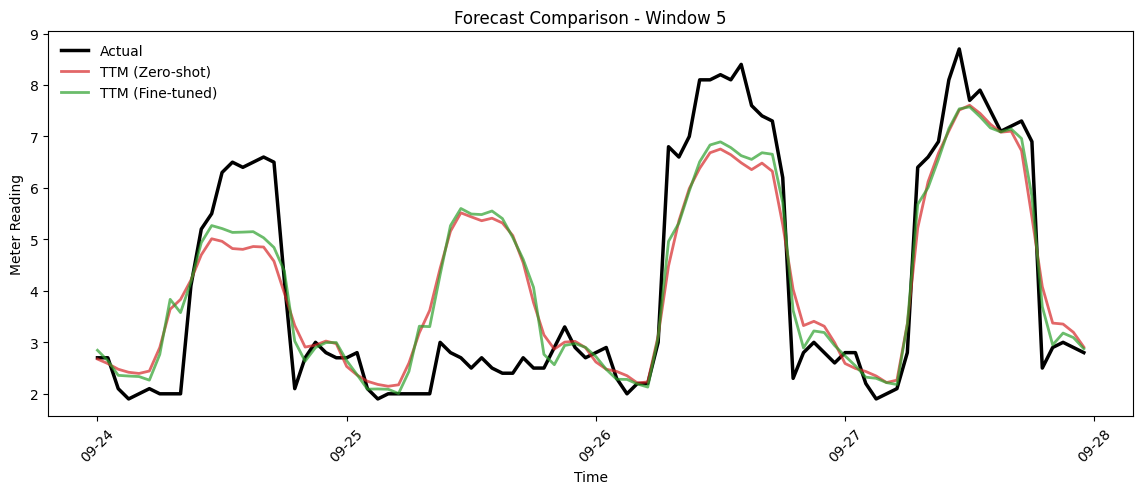

In [21]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

model_time_index = test.index[168:]

actual = test["meter_reading"].iloc[168:].values

ttm_zs_pred = np.asarray(y_pred_unscaled_ttm_zs)
ttm_ft_pred = np.asarray(y_pred_unscaled_ttm_ft)

# Align lengths
min_len = min(
    len(model_time_index),
    len(actual),
    len(ttm_zs_pred),
    len(ttm_ft_pred),
)

model_time_index = model_time_index[:min_len]
actual = actual[:min_len]
ttm_zs_pred = ttm_zs_pred[:min_len]
ttm_ft_pred = ttm_ft_pred[:min_len]


num_plots = 5
window_size = 96      # 4 days
window_stride = 96    # Move 4 days each time

for i in range(num_plots):

    start = i * window_stride
    end = min(start + window_size, min_len)

    fig, ax = plt.subplots(figsize=(14, 5))

    ax.plot(
        model_time_index[start:end],
        actual[start:end],
        color="black",
        linewidth=2.5,
        label="Actual",
    )

    ax.plot(
        model_time_index[start:end],
        ttm_zs_pred[start:end],
        color="tab:red",
        linewidth=2,
        label="TTM (Zero-shot)",
        alpha=0.7
    )

    ax.plot(
        model_time_index[start:end],
        ttm_ft_pred[start:end],
        color="tab:green",
        linewidth=2,
        label="TTM (Fine-tuned)",
        alpha=0.7
    )

    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))

    plt.xticks(rotation=45)
    plt.xlabel("Time")
    plt.ylabel("Meter Reading")
    plt.title(f"Forecast Comparison - Window {i+1}")

    ax.legend(
        loc="upper left",
        # bbox_to_anchor=(1.02, 0.5),
        frameon=False,
    )

    # plt.tight_layout(rect=[0, 0, 0.83, 1])
    plt.show()

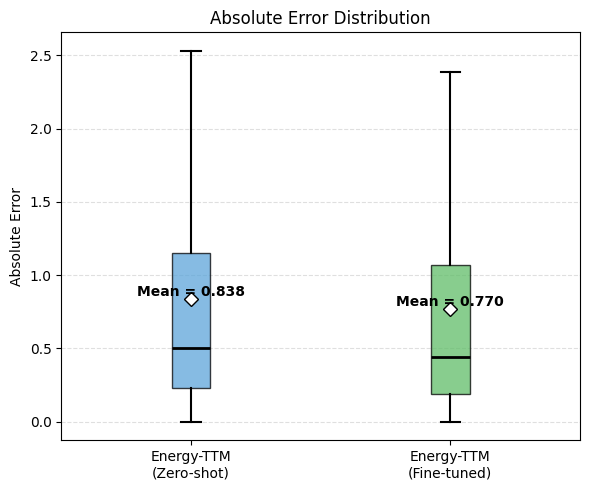

In [22]:
import matplotlib.pyplot as plt
import numpy as np

err_zs = np.abs(actual - ttm_zs_pred)
err_ft = np.abs(actual - ttm_ft_pred)

mae_zs = err_zs.mean()
mae_ft = err_ft.mean()

median_zs = np.median(err_zs)
median_ft = np.median(err_ft)

fig, ax = plt.subplots(figsize=(6, 5))

box = ax.boxplot(
    [err_zs, err_ft],
    labels=["Energy-TTM\n(Zero-shot)", "Energy-TTM\n(Fine-tuned)"],
    patch_artist=True,
    showmeans=True,
    showfliers=False,
    meanprops=dict(
        marker="D",
        markerfacecolor="white",
        markeredgecolor="black",
        markersize=7,
    ),
    medianprops=dict(
        color="black",
        linewidth=2,
    ),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
)

# Colors
colors = ["#5DA5DA", "#60BD68"]  # blue, green

for patch, color in zip(box["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

# Annotate MAE
for i, mae in enumerate([mae_zs, mae_ft], start=1):
    ax.text(
        i,
        mae,
        f"Mean = {mae:.3f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )

ax.set_ylabel("Absolute Error")
ax.set_title("Absolute Error Distribution")

ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Flatten arrays
y_true = y_true_unscaled_ttm_zs.reshape(-1)
y_pred_ttm_zs = y_pred_unscaled_ttm_zs.reshape(-1)
y_pred_ttm_ft = y_pred_unscaled_ttm_ft.reshape(-1)

# Align lengths
common_len = min(
    len(y_true),
    len(y_pred_ttm_zs),
    len(y_pred_ttm_ft),
)

y_true = y_true[:common_len]
y_pred_ttm_zs = y_pred_ttm_zs[:common_len]
y_pred_ttm_ft = y_pred_ttm_ft[:common_len]

# ---------------- Zero-shot TTM ----------------
mae_zs = mean_absolute_error(y_true, y_pred_ttm_zs)
rmse_zs = np.sqrt(mean_squared_error(y_true, y_pred_ttm_zs))

# ---------------- Fine-tuned TTM ----------------
mae_ft = mean_absolute_error(y_true, y_pred_ttm_ft)
rmse_ft = np.sqrt(mean_squared_error(y_true, y_pred_ttm_ft))

print("TTM (Zero-shot)")
print(f"MAE  : {mae_zs:.4f}")
print(f"RMSE : {rmse_zs:.4f}")

print()

print("TTM (Fine-tuned)")
print(f"MAE  : {mae_ft:.4f}")
print(f"RMSE : {rmse_ft:.4f}")

TTM (Zero-shot)
MAE  : 0.8381
RMSE : 1.2209

TTM (Fine-tuned)
MAE  : 0.7702
RMSE : 1.1586


: 